# Zig ConvNet vs PyTorch Reference

Side-by-side validation of `visual/outputs/bin/visual` against PyTorch `weights_best.pth`.
Uses the first image from each class in `training/dataset/`.

In [1]:
import subprocess, os, sys
import numpy as np
import torch
from torch import nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cwd = os.getcwd()
if os.path.basename(cwd) == 'visual':
    repo_root = os.path.dirname(cwd)
else:
    repo_root = cwd
training_dir = os.path.join(repo_root, 'training')
weights_path = os.path.join(training_dir, 'weights_best.pth')
dataset_dir = os.path.join(training_dir, 'dataset')
binary_path = os.path.join(repo_root, 'visual', 'outputs', 'bin', 'visual')

classes = sorted([d for d in os.listdir(dataset_dir)
                  if os.path.isdir(os.path.join(dataset_dir, d))])
print(f"Binary: {binary_path}")
print(f"Weight: {weights_path}")
print(f"Dataset: {dataset_dir}")
print(f"Classes ({len(classes)}): {classes}")

Binary: /Users/bitan/Desktop/pixy/visual/outputs/bin/visual
Weight: /Users/bitan/Desktop/pixy/training/weights_best.pth
Dataset: /Users/bitan/Desktop/pixy/training/dataset
Classes (9): ['angry', 'confused', 'cross', 'flabbergasted', 'happy', 'heart', 'question', 'sad', 'tick']


## Load PyTorch model with trained weights

In [2]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 5, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(5, 5, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(5, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.Conv2d(8, 8, kernel_size=3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(),
        )
        self.fc = nn.Sequential(
            nn.Linear(14 * 14 * 16, 100), nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(100, len(classes)),
        )
    def forward(self, x):
        out = self.layer1(x)
        out = out.view(out.shape[0], -1)
        out = self.fc(out)
        return out

model = Net()
sd = torch.load(weights_path, map_location='cpu', weights_only=True)
model.load_state_dict(sd)
model.eval()
print("PyTorch model loaded")

PyTorch model loaded


## Load first image from each class

In [3]:
transform = transforms.Compose([
    transforms.Resize((56, 56)),
    transforms.ToTensor(),
])

images = []
labels = []
for cls in classes:
    cls_dir = os.path.join(dataset_dir, cls)
    first = sorted(f for f in os.listdir(cls_dir) if f.lower().endswith('.png'))[0]
    path = os.path.join(cls_dir, first)
    img = Image.open(path).convert('L')
    tensor = transform(img)
    images.append(tensor)
    labels.append(cls)

print(f"Loaded {len(images)} images ({len(labels)} labels)")

Loaded 9 images (9 labels)


## Compute logits side by side

In [4]:
ref_logits_list = []
zig_logits_list = []

with torch.no_grad():
    for tensor in images:
        ref = model(tensor.unsqueeze(0)).squeeze(0).numpy()
        ref_logits_list.append(ref)

        raw_bytes = tensor.numpy().flatten().astype('float32').tobytes()
        result = subprocess.run([binary_path], input=raw_bytes, capture_output=True)
        zig = np.array([float(x) for x in result.stdout.decode().strip().split()])
        zig_logits_list.append(zig)

ref_logits = np.array(ref_logits_list)
zig_logits = np.array(zig_logits_list)
print(f"Reference shape: {ref_logits.shape}")
print(f"Zig shape:       {zig_logits.shape}")
print(f"Max diff:        {np.max(np.abs(ref_logits - zig_logits)):.6e}")

Reference shape: (9, 9)
Zig shape:       (9, 9)
Max diff:        6.444092e-06


## Side-by-side comparison table

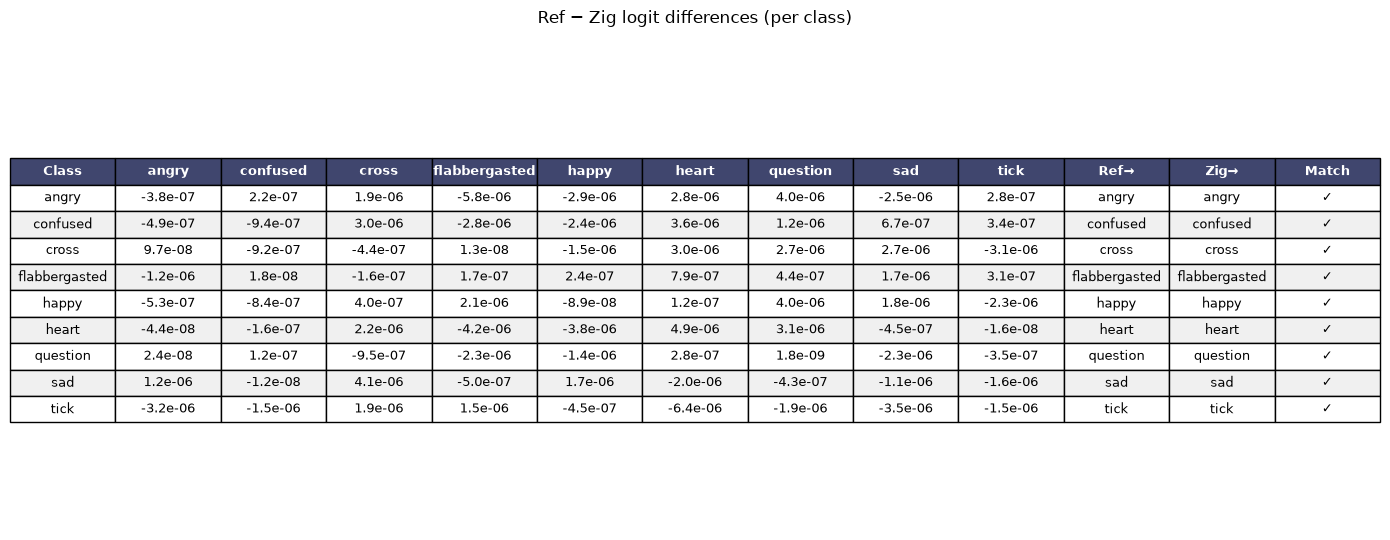

In [5]:
headers = ["Class"] + classes + ["Ref→", "Zig→", "Match"]
rows = []
for i, cls in enumerate(labels):
    row = [cls]
    for j in range(len(classes)):
        d = ref_logits[i, j] - zig_logits[i, j]
        if abs(d) > 1e-4:
            s = f"{d:+.2e}"
        else:
            s = f"{d:.1e}"
        row.append(s)
    ref_pred = classes[ref_logits[i].argmax()]
    zig_pred = classes[zig_logits[i].argmax()]
    row.append(ref_pred)
    row.append(zig_pred)
    row.append("✓" if ref_pred == zig_pred else "✗")
    rows.append(row)

fig, ax = plt.subplots(figsize=(14, len(labels) * 0.5 + 1))
ax.axis('off')
table = ax.table(cellText=rows, colLabels=headers, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)
for (row, _), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#40466e')
        cell.set_text_props(color='white', weight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f0f0f0')
plt.title("Ref − Zig logit differences (per class)", fontsize=12, pad=20)
plt.tight_layout()
plt.show()

## Image grid with predictions

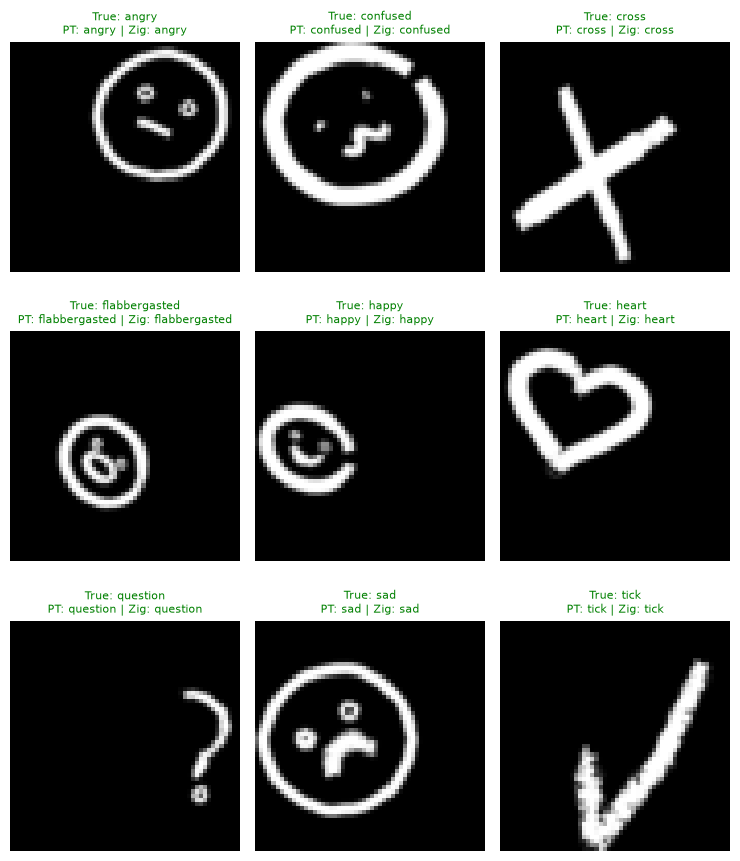

In [6]:
num = len(images)
cols = 3
rows = (num + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 3))
axes = axes.flatten()

for i, tensor in enumerate(images):
    ref_pred = classes[ref_logits[i].argmax()]
    zig_pred = classes[zig_logits[i].argmax()]
    true_cls = labels[i]
    color = "green" if ref_pred == true_cls else "red"
    axes[i].imshow(tensor.squeeze(), cmap='gray')
    axes[i].set_title(f"True: {true_cls}\nPT: {ref_pred} | Zig: {zig_pred}",
                     fontsize=8, color=color)
    axes[i].axis('off')

for i in range(num, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Logit bar chart (PyTorch vs Zig)

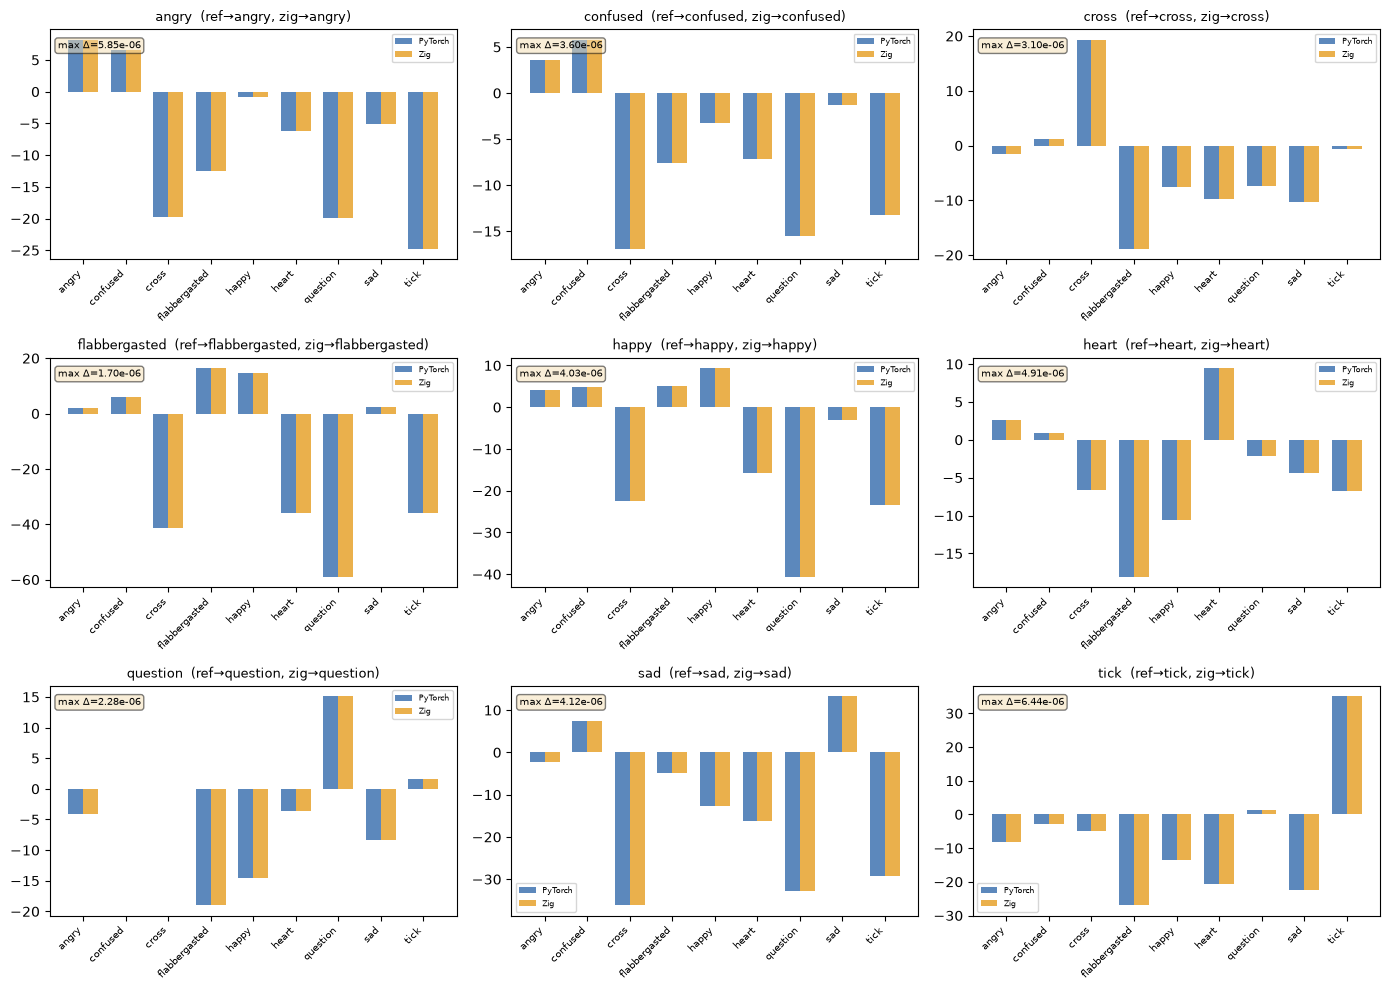

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i in range(9):
    ax = axes[i]
    x = np.arange(len(classes))
    w = 0.35
    ax.bar(x - w/2, ref_logits[i], w, label='PyTorch', color='#4a7bb5', alpha=0.9)
    ax.bar(x + w/2, zig_logits[i], w, label='Zig', color='#e8a838', alpha=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_title(f"{labels[i]}  (ref→{classes[ref_logits[i].argmax()]}, zig→{classes[zig_logits[i].argmax()]})", fontsize=9)
    ax.legend(fontsize=6)
    max_diff = np.max(np.abs(ref_logits[i] - zig_logits[i]))
    ax.text(0.02, 0.95, f"max Δ={max_diff:.2e}", transform=ax.transAxes,
            fontsize=7, va='top', bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Summary

In [8]:
diffs = np.abs(ref_logits - zig_logits)
pred_match = (ref_logits.argmax(axis=1) == zig_logits.argmax(axis=1))

print(f"{'='*50}")
print(f"  Prediction match:  {pred_match.sum()} / {len(pred_match)}")
print(f"  Max logit diff:    {diffs.max():.6e}")
print(f"  Mean logit diff:   {diffs.mean():.6e}")
print(f"  Median logit diff: {np.median(diffs):.6e}")
print(f"{'='*50}")
print()

if pred_match.all() and diffs.max() < 1e-3:
    print("✓ VALIDATION PASSED — Zig implementation matches PyTorch reference.")
else:
    print("✗ VALIDATION FAILED — Differences exceed tolerance.")

  Prediction match:  9 / 9
  Max logit diff:    6.444092e-06
  Mean logit diff:   1.594072e-06
  Median logit diff: 1.247681e-06

✓ VALIDATION PASSED — Zig implementation matches PyTorch reference.
